# Single-unit responses to social and non-social fixations

**Thesis chapter results — part 1.**

Neurons were recorded simultaneously from the basolateral amygdala (BLA) together
with one of three prefrontal regions — gyral anterior cingulate cortex (ACCg),
dorsomedial prefrontal cortex (dmPFC), or orbitofrontal cortex (OFC) — while two
macaques freely viewed one another. Every fixation falls into one of three
categories: **interactive face**, **non-interactive face**, or **object**.

The argument, in order:

| § | Claim |
|---|---|
| 2 | Individual neurons are selective for interactive face fixations. |
| 3 | Interactive face is the most frequently preferred category across the population. |
| 4 | But different subpopulations differentiate different fixation pairs — selectivity is not one thing. |
| 5 | Two metrics describe the firing-rate profile: **main-peak halfwidth** and **peak isolation**. |
| 6 | Selective neurons occupy a continuum in that space, not discrete types. |
| 7 | Halfwidth differs by fixation category (supplementary). |

Every figure is one row of four region panels, saved as an Illustrator-editable
PDF (embedded TrueType, no clipping masks) plus a 400 dpi PNG. All plotting lives
in `src/dal_monte_2022_analysis/ephys/plotting/`; this notebook orchestrates and
displays only.

## 1 · Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit as figs
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit_data as data
from dal_monte_2022_analysis.ephys.plotting import thesis_metric_space as space
from dal_monte_2022_analysis.ephys.plotting import thesis_trace_metrics as metrics
from dal_monte_2022_analysis.ephys.analysis.fixation_peakiness import (
    decompose_dominant_peak_prominence,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
PSTH_CFG_PATH = repo_root / "configs" / "ephys_fixation_psth.yaml"

dataset_cfg = load_config(DATASET_CFG_PATH)
plotting_cfg = load_config(PLOTTING_CFG_PATH)
psth_cfg = load_config(PSTH_CFG_PATH)

style.apply_thesis_plot_style(plotting_cfg)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

ANALYSIS_ROOT = data.resolve_psth_analysis_root(dataset_cfg)
FIGURE_SETTINGS = style.ThesisFigureSettings(output_dir=ANALYSIS_ROOT / "single_unit_thesis")
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

FIGURE_MANIFEST: dict[str, dict[str, Path]] = {}

In [2]:
units = data.load_thesis_unit_table(ANALYSIS_ROOT)
pair_selectivity = data.load_pair_selectivity(ANALYSIS_ROOT)
condition_traces = data.load_condition_traces(ANALYSIS_ROOT)
trace_shape = data.load_trace_shape_table(ANALYSIS_ROOT, units)
trace_shape_all = data.load_trace_shape_table(ANALYSIS_ROOT, units, condition="all")
matched_cv, matched_cv_stats, cv_inflation = data.load_trial_matched_cv(ANALYSIS_ROOT)

unit_plot_settings = data.build_unit_plot_settings(
    DATASET_CFG_PATH, PLOTTING_CFG_PATH, psth_cfg
)
peakiness_settings = data.build_peakiness_settings(DATASET_CFG_PATH, psth_cfg)

print(f"{len(units)} units | {units['is_selective'].sum()} fixation-category-modulated")
print(f"{units['date'].nunique()} sessions | figures -> {FIGURE_SETTINGS.output_dir}")

1201 units | 574 fixation-category-modulated
42 sessions | figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/single_unit_thesis


## 2 · Neurons selective for interactive face fixations

Four example units, one per region. Each is significant on **both** interactive-face
contrasts (int vs non-int face, and int vs object) after FDR correction, and each
fires most for interactive face across the fixation window.

Rasters are subsampled to 70 trials per category so individual spikes stay visible;
the firing-rate traces use all trials (mean ± SEM, 10 ms bins, 20 ms Gaussian
smoothing). The three grey bars mark the analysis windows used in §4.

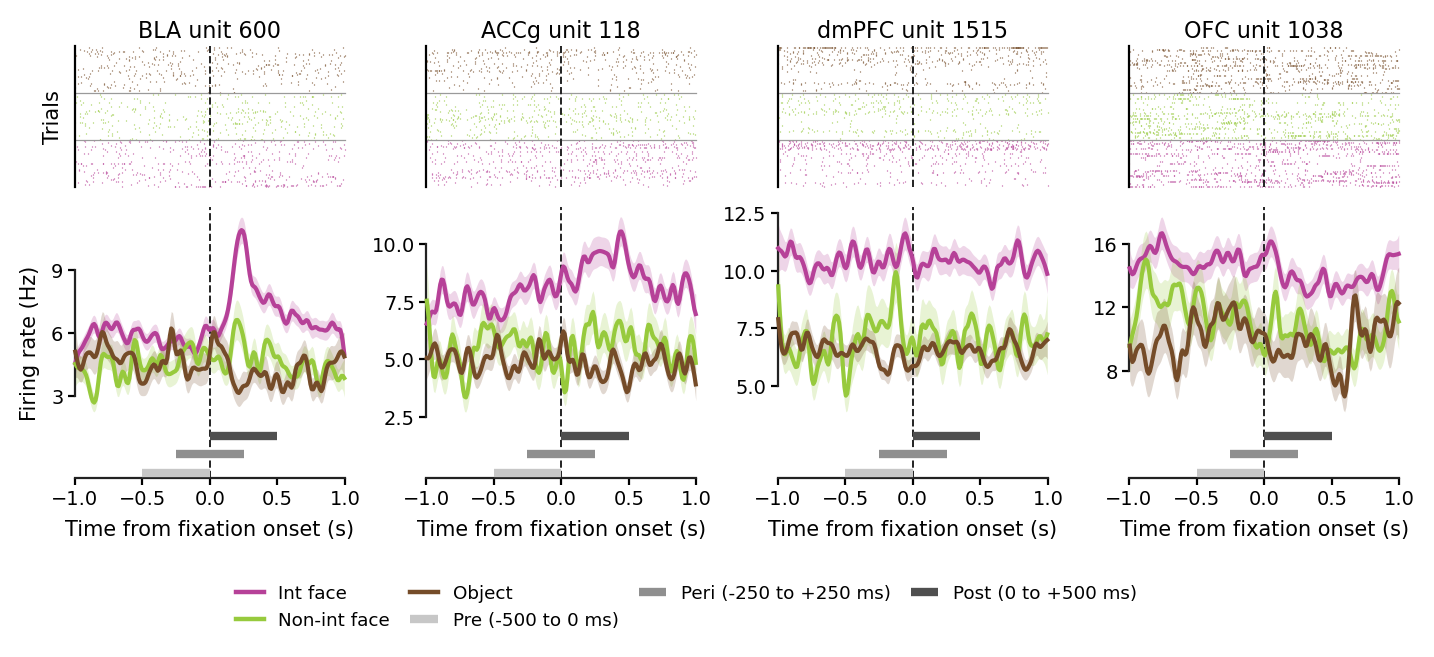

,region_label,uuid,date,mean_fr_face_interactive_hz,mean_fr_face_non_interactive_hz,mean_fr_object_hz,n_selective_pairs
0,BLA,600,2062018,6.80,4.92,4.40,2
1,ACCg,118,1172018,8.54,5.62,4.87,3
2,dmPFC,1515,2072018,10.49,7.23,6.46,2
3,OFC,1038,2062018,14.45,10.84,10.17,2


In [3]:
INT_FACE_EXAMPLES = {"bla": "600", "accg": "118", "dmpfc": "1515", "ofc": "1038"}

example_units = data.build_exemplar_table(
    units, {region: {"int_face": uuid} for region, uuid in INT_FACE_EXAMPLES.items()}
)
example_specs = data.build_example_unit_panel_specs(
    example_units,
    style="int_face",
    unit_settings=unit_plot_settings,
    peakiness_settings=peakiness_settings,
    condition_traces=condition_traces,
)
fig = figs.plot_example_unit_panel(example_specs, show_window_legend=True)
FIGURE_MANIFEST["fig01_interactive_face_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig01_interactive_face_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))

window_means = pd.read_csv(
    ANALYSIS_ROOT / "fixation_psth_selectivity" / "condition_window_means.csv"
)
window_means = window_means.loc[window_means["window_name"] == "full_fix"]
display(
    example_units.merge(
        window_means.loc[
            :,
            ["unit_key", "mean_fr_face_interactive_hz", "mean_fr_face_non_interactive_hz",
             "mean_fr_object_hz"],
        ],
        on="unit_key",
        how="left",
    ).loc[
        :, ["region_label", "uuid", "date", "mean_fr_face_interactive_hz",
            "mean_fr_face_non_interactive_hz", "mean_fr_object_hz", "n_selective_pairs"]
    ].round(2)
)

## 3 · Interactive face is the preferred category across the population

A unit counts as **fixation-category-modulated** if its firing rate differs
significantly between at least one category pair in at least one of three 500 ms
windows (Welch's *t*-test on per-trial window means, FDR corrected across all
pair × window tests within the unit). For each such unit, the panel below asks
which category evoked the highest mean rate over the full −500 to +500 ms window.

Bars carry Wilson 95% intervals and a binomial test against chance (1/3), FDR
corrected across the region × category family; the pie inset shows composition,
which cannot carry uncertainty and is therefore secondary.

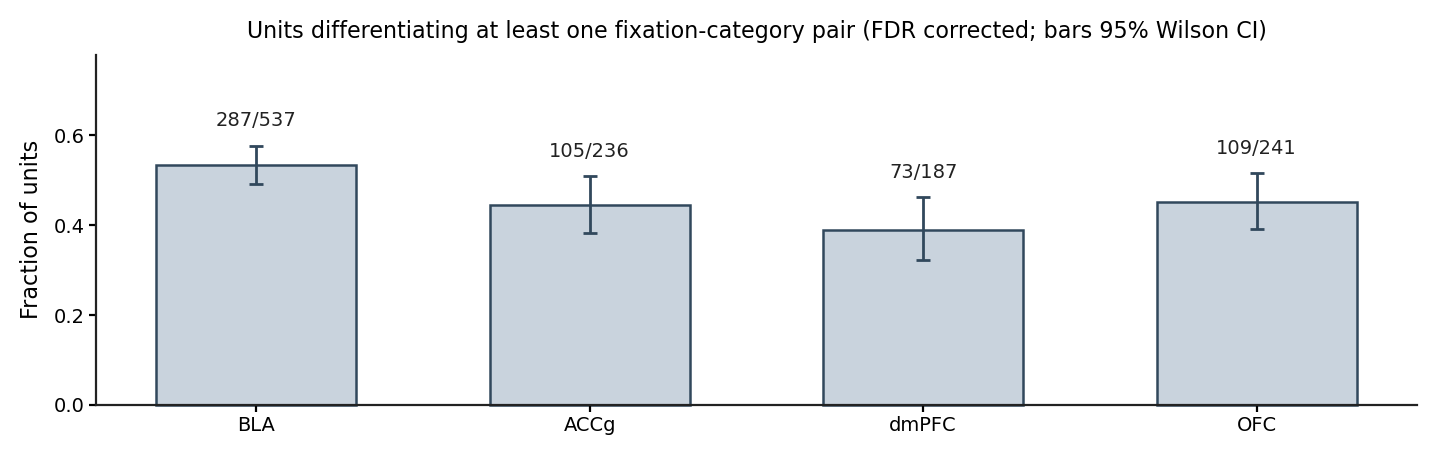

,region,region_label,n_units,n_selective,fraction,ci_low,ci_high,n_sessions
0,bla,BLA,537,287,0.534,0.492,0.576,35
1,accg,ACCg,236,105,0.445,0.383,0.509,19
2,dmpfc,dmPFC,187,73,0.390,0.323,0.462,17
3,ofc,OFC,241,109,0.452,0.391,0.515,14


In [4]:
fig, yield_table = figs.plot_unit_yield_panel(units)
FIGURE_MANIFEST["fig02_unit_yield"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig02_unit_yield"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(yield_table.round(3))

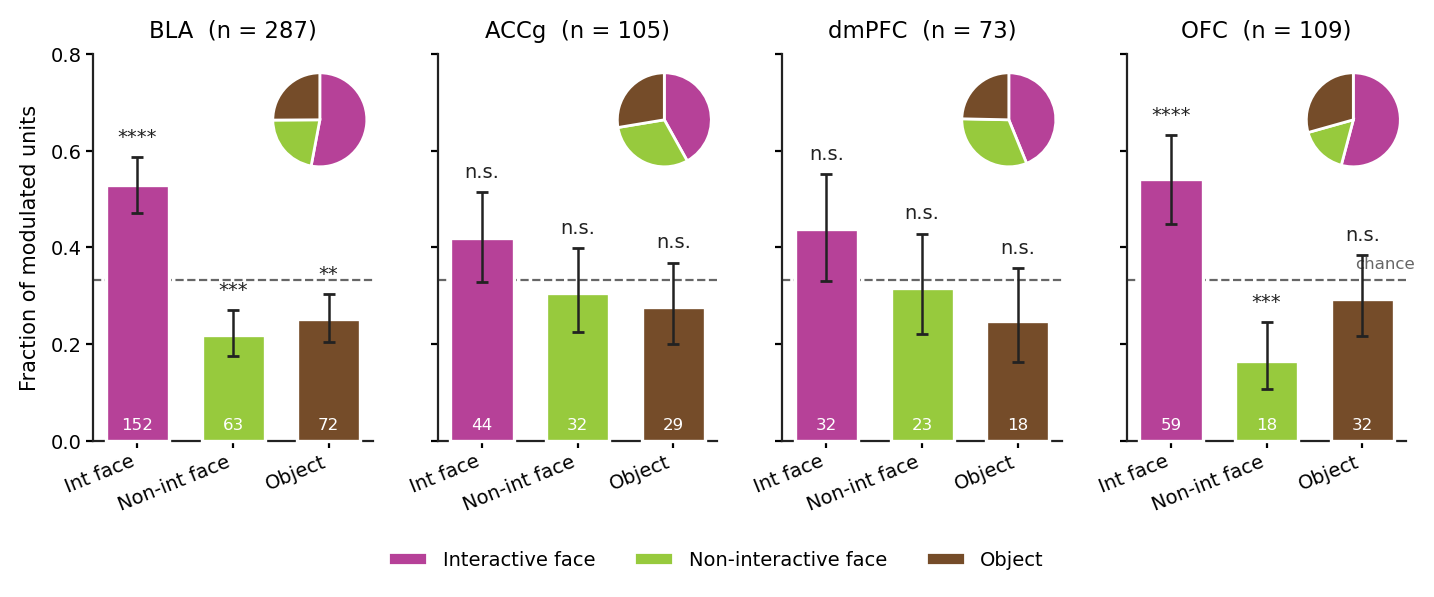

,region_label,condition,k,n,fraction,ci_low,ci_high,p_adj,stars
0,BLA,face_interactive,152,287,0.5296,0.4719,0.5866,0.0000,****
1,BLA,face_non_interactive,63,287,0.2195,0.1755,0.2709,0.0001,***
2,BLA,object,72,287,0.2509,0.2042,0.3041,0.0063,**
3,ACCg,face_interactive,44,105,0.4190,0.3292,0.5146,0.1333,n.s.
4,ACCg,face_non_interactive,32,105,0.3048,0.2249,0.3984,0.6600,n.s.
5,ACCg,object,29,105,0.2762,0.1997,0.3685,0.3395,n.s.
6,dmPFC,face_interactive,32,73,0.4384,0.3305,0.5524,0.1253,n.s.
7,dmPFC,face_non_interactive,23,73,0.3151,0.2200,0.4286,0.8047,n.s.
8,dmPFC,object,18,73,0.2466,0.1620,0.3564,0.2040,n.s.
9,OFC,face_interactive,59,109,0.5413,0.4479,0.6318,0.0001,****


In [5]:
fig, preference_table = figs.plot_preferred_condition_panel(units.loc[units["is_selective"]])
FIGURE_MANIFEST["fig03_preferred_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig03_preferred_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    preference_table.loc[
        :, ["region_label", "condition", "k", "n", "fraction", "ci_low", "ci_high",
            "p_adj", "stars"]
    ].round(4)
)

## 4 · Different subpopulations differentiate different fixation pairs

Preference for interactive face is not the whole story: units also separate
non-interactive face from object, and many separate more than one pair. The UpSet
plot below partitions each region's selective units by exactly which pairs they
separate.

An UpSet rather than a Venn: three-set Venns cannot in general be drawn
area-proportionally — some combinations of the seven subset sizes admit no valid
circle geometry — and per-region area scaling would give each of the four panels a
different shape, defeating the comparison. Bars are the fraction of each region's
selective units so regions are comparable despite differing yields; unit counts are
printed on each bar.

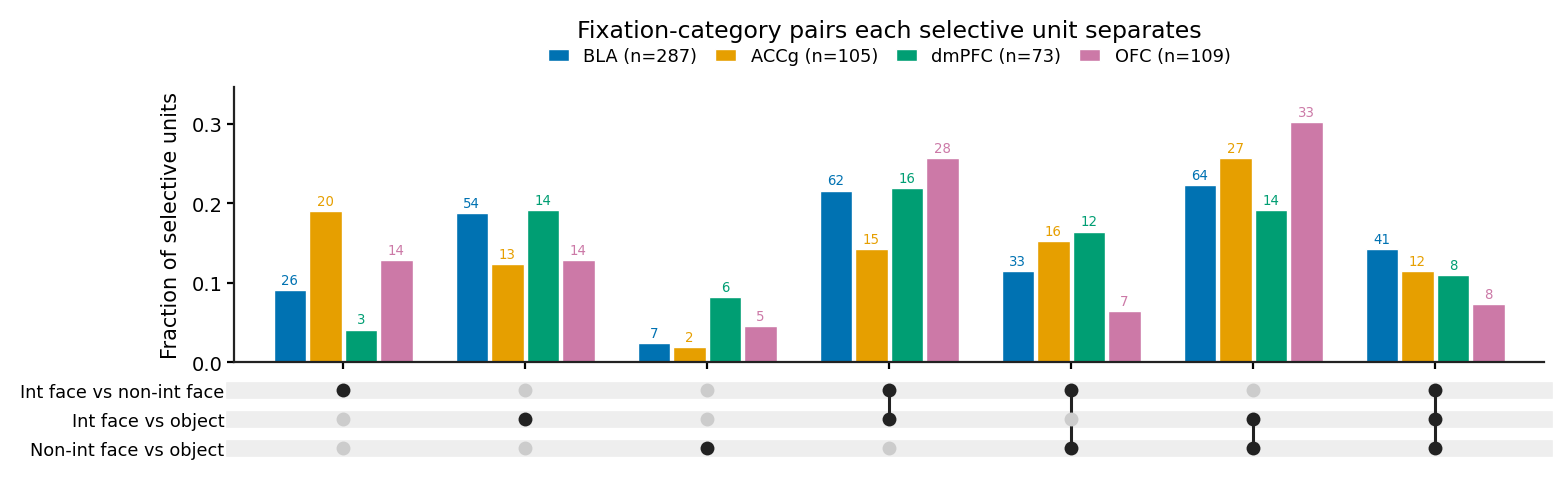

,region,region_label,100,010,001,110,101,011,111,n_selective,n_units
0,bla,BLA,26,54,7,62,33,64,41,287,537
1,accg,ACCg,20,13,2,15,16,27,12,105,236
2,dmpfc,dmPFC,3,14,6,16,12,14,8,73,187
3,ofc,OFC,14,14,5,28,7,33,8,109,241


In [6]:
pair_membership = figs.compute_pair_selectivity_membership(pair_selectivity)
fig, upset_counts = figs.plot_pair_selectivity_upset_panel(
    pair_membership,
    region_totals=units.groupby("region").size().to_dict(),
)
FIGURE_MANIFEST["fig04_pair_selectivity_upset"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig04_pair_selectivity_upset"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(upset_counts)

## 5 · Two metrics for the firing-rate profile

Selective units differ in *how* their rate changes, not only in which category they
prefer. Two quantities, both measured on the trace of the unit's preferred category,
capture the two things that vary:

- **Main-peak halfwidth** — full width at half maximum of the excess response (ms).
  How long the response is held.
- **Peak isolation** — $1 - P_2/P_1$, where $P_1$ is the main peak's topographic
  prominence and $P_2$ the largest prominence at least 250 ms away. High values mean
  the main peak clearly **dominates** its strongest rival; low values mean it is
  **rivalled** by a second peak of comparable prominence.

The two axes therefore read as *narrow versus wide* (halfwidth) and *dominant versus
rivalled* (isolation), and the corner labels in §6 use exactly those words.

They replace the single composite score used previously. That composite,
$P_1/(1+\lambda P_2/P_1)$, correlates **0.99 with $P_1$ alone** — the discount term
spans too little range to matter — so it measured peak *height* while being
described as measuring isolation, and peak height is exactly the quantity trial
count corrupts. Halfwidth and isolation are near-independent (ρ ≈ −0.26) and both
are trial-count insensitive (ρ = +0.12 and −0.001).

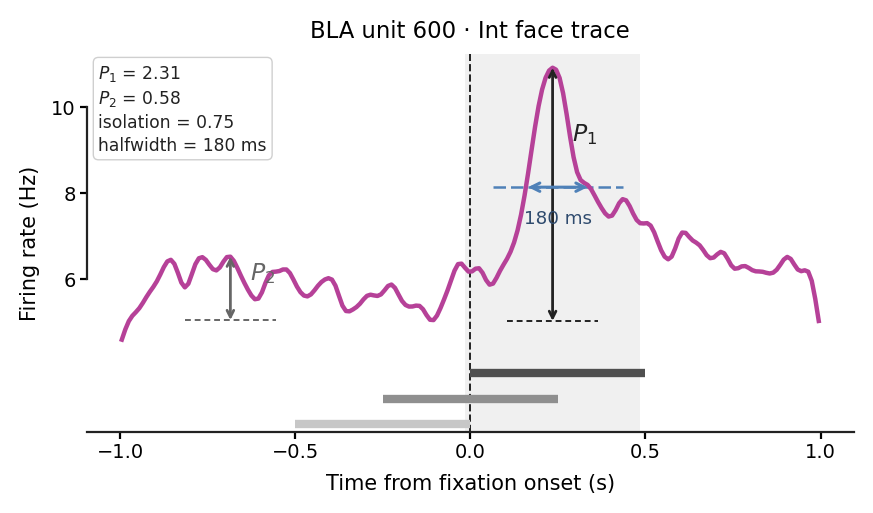

In [7]:
schematic_row = condition_traces.loc[
    (condition_traces["unit_uuid"] == "unit_uuid__600")
    & (condition_traces["condition"] == "face_interactive")
].iloc[0]
schematic_decomposition = decompose_dominant_peak_prominence(
    np.asarray(schematic_row["trace_hz"], dtype=float),
    np.asarray(schematic_row["bin_centers_s_rel"], dtype=float),
    peakiness_settings,
)
schematic_halfwidth = float(
    trace_shape.loc[trace_shape["uuid"] == "600", "response_duration_ms"].iloc[0]
)
fig = space.plot_isolation_schematic(
    schematic_decomposition, unit_label="BLA unit 600", duration_ms=schematic_halfwidth
)
FIGURE_MANIFEST["fig05_metric_schematic"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig05_metric_schematic"
)
display(Image(data=style.figure_to_png_bytes(fig)))

## 6 · Selective units occupy a continuum, not discrete types

Plotted against each other, the modulated population forms a **single unimodal
cloud** in every region. There is no narrow/wide or dominant/rivalled dichotomy to
threshold — which is why these are treated as descriptive axes rather than a
taxonomy. Naming the corners is still useful, and each corner unit's own firing-rate
trace (its preferred category only) is inset beside its point so a coordinate in
this space can be read directly as a response shape.

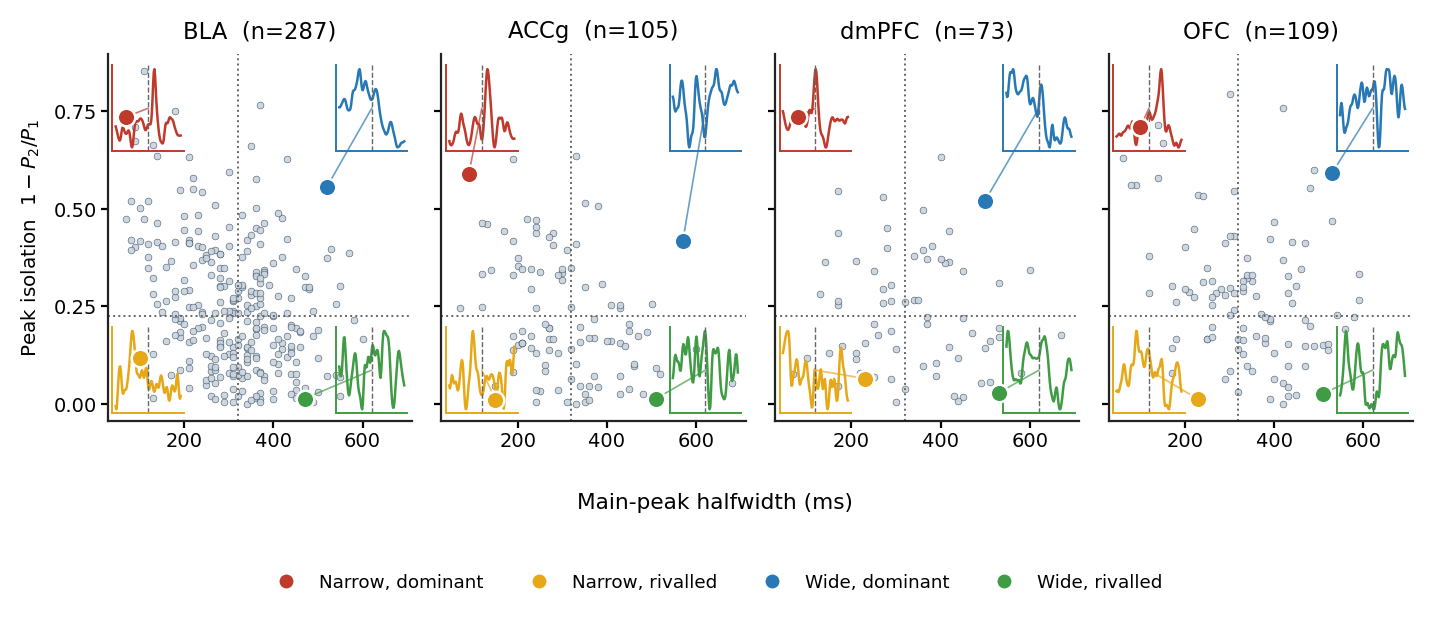

,region,n_units,halfwidth_median_ms,isolation_median,spearman_rho
0,BLA,287,310.0,0.232,-0.298
1,ACCg,105,300.0,0.175,-0.314
2,dmPFC,73,340.0,0.205,-0.090
3,OFC,109,340.0,0.274,-0.275


,region,corner,uuid,date,condition,response_duration_ms,peak_isolation,mean_fr_hz
0,bla,"Narrow, dominant",2635,1102019,face_interactive,70.0,0.74,6.28
1,bla,"Narrow, rivalled",2710,1142019,object,100.0,0.12,4.31
2,bla,"Wide, dominant",2697,1132019,object,520.0,0.56,12.80
3,bla,"Wide, rivalled",732,8312018,face_interactive,470.0,0.01,3.94
4,accg,"Narrow, dominant",380,1172019,object,90.0,0.59,3.28
5,accg,"Narrow, rivalled",390,1172019,face_interactive,150.0,0.01,4.49
6,accg,"Wide, dominant",129,1172018,face_interactive,570.0,0.42,22.31
7,accg,"Wide, rivalled",335,1132019,object,510.0,0.01,12.24
8,dmpfc,"Narrow, dominant",1771,1092019,face_interactive,80.0,0.74,5.14
9,dmpfc,"Narrow, rivalled",1741,1082019,face_interactive,230.0,0.07,8.97


In [8]:
corner_units = pd.concat(
    [space.select_corner_units(trace_shape, region=region) for region in style.REGION_ORDER],
    ignore_index=True,
)
fig, metric_space_summary = space.plot_metric_space_panel(
    trace_shape, corners=corner_units, condition_traces=condition_traces
)
FIGURE_MANIFEST["fig06_metric_space"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig06_metric_space"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(metric_space_summary.round(3))
display(
    corner_units.loc[
        :, ["region", "corner", "uuid", "date", "condition", "response_duration_ms",
            "peak_isolation", "mean_fr_hz"]
    ].round(2)
)

## 7 · Halfwidth by fixation category — supplementary

Within unit, is the response to one category held longer than to another? Violins
follow the project's behavioural convention (seaborn, quartile lines inside, kernel
truncated at the data range). Paired *t*-tests, FDR corrected across the whole
region × comparison family.

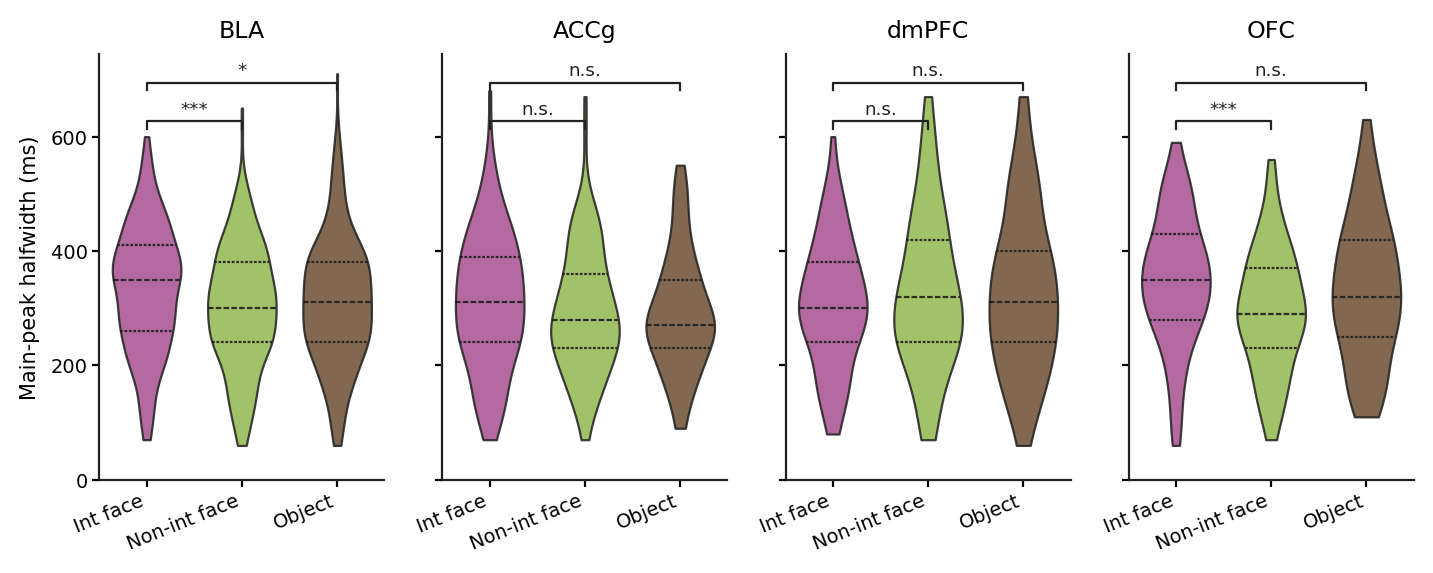

,region_label,condition_b,n_units,median_a,median_b,statistic,p_adj,stars
0,BLA,face_non_interactive,287,350.0,300.0,3.749,0.001,***
1,BLA,object,287,350.0,310.0,2.481,0.036,*
2,ACCg,face_non_interactive,105,310.0,280.0,1.075,0.380,n.s.
3,ACCg,object,105,310.0,270.0,1.472,0.288,n.s.
4,dmPFC,face_non_interactive,73,300.0,320.0,-0.884,0.380,n.s.
5,dmPFC,object,73,300.0,310.0,-0.918,0.380,n.s.
6,OFC,face_non_interactive,109,350.0,290.0,3.896,0.001,***
7,OFC,object,109,350.0,320.0,1.094,0.380,n.s.


In [9]:
fig, halfwidth_table = figs.plot_condition_metric_panel(
    trace_shape_all.loc[trace_shape_all["is_selective"]],
    metric="response_duration_ms",
    metric_label=space.HALFWIDTH_LABEL,
)
FIGURE_MANIFEST["fig07_halfwidth_by_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig07_halfwidth_by_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    halfwidth_table.loc[
        :, ["region_label", "condition_b", "n_units", "median_a", "median_b",
            "statistic", "p_adj", "stars"]
    ].round(3)
)

### Methods note: why halfwidth and not the coefficient of variation

The obvious alternative — the CV of the mean firing-rate trace across time bins —
is **not usable for comparing fixation categories here**. Interactive-face fixations
are about five times more numerous than the others (median 846 trials per unit
versus 168 and 168). The number of time bins is identical in every condition, but
that does not protect the statistic: each bin of the mean trace is itself a trial
average, so writing `m(t) = s(t) + e(t)` gives

$$\operatorname{Var}_t[m] \approx \operatorname{Var}_t[s] + \mathbb{E}[\sigma^2]/N$$

and a condition observed with fewer trials inherits extra across-bin variance from
estimation noise alone. Equalising trial counts within unit and recomputing from 25
matched subsamples removes the apparent interactive-face advantage entirely. The
right panel shows the mechanism: subsampling interactive-face trials, holding
condition and neural signal fixed, inflates that condition's own CV by up to 2.4×.
Halfwidth is a width rather than an amplitude and is not affected.

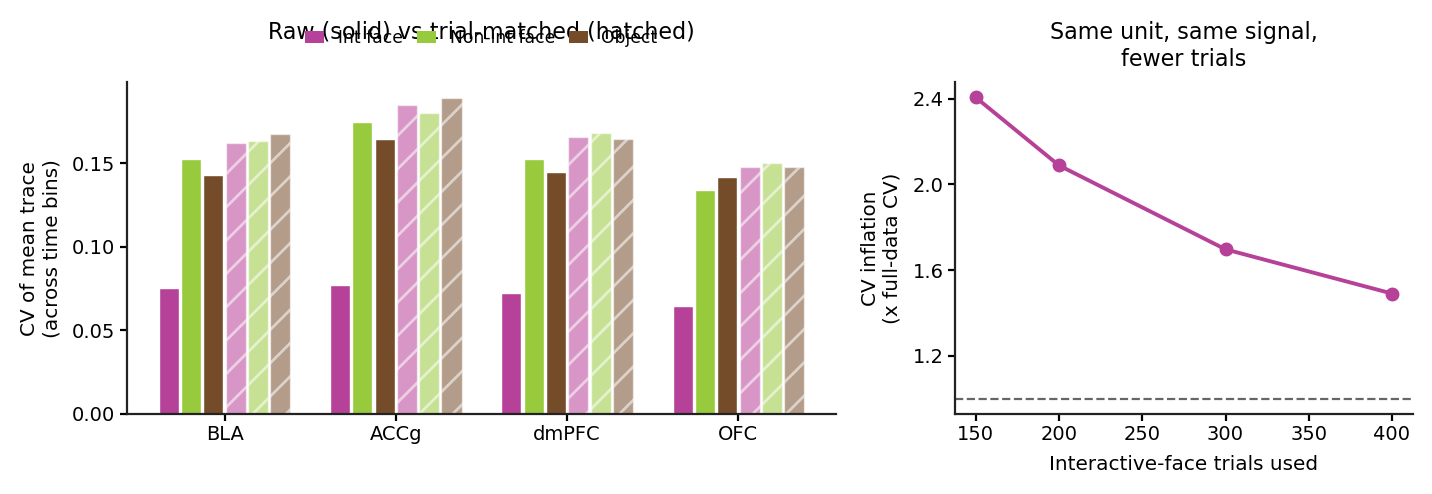

,region,variant,condition_b,n_units_paired,median_a,median_b,statistic,p_value_adjusted,significant_adjusted
0,ofc,cv_full,face_non_interactive,241,0.0646,0.1339,-18.3136,0.0000,True
1,ofc,cv_full,object,241,0.0646,0.1418,-16.7915,0.0000,True
3,ofc,cv_matched,face_non_interactive,241,0.1474,0.1502,-1.3319,0.2762,False
4,ofc,cv_matched,object,241,0.1474,0.1474,-2.5007,0.0314,True
6,bla,cv_full,face_non_interactive,537,0.0754,0.1522,-25.1123,0.0000,True
7,bla,cv_full,object,537,0.0754,0.1427,-20.4079,0.0000,True
9,bla,cv_matched,face_non_interactive,537,0.1618,0.1629,-1.7161,0.1735,False
10,bla,cv_matched,object,537,0.1618,0.1671,-2.6004,0.0314,True
12,accg,cv_full,face_non_interactive,236,0.0771,0.1746,-18.7120,0.0000,True
13,accg,cv_full,object,236,0.0771,0.1642,-17.0738,0.0000,True


In [10]:
fig = space.plot_cv_trial_matched_control(matched_cv, cv_inflation)
FIGURE_MANIFEST["fig08_cv_trial_matched_control"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig08_cv_trial_matched_control"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    matched_cv_stats.loc[
        matched_cv_stats["condition_a"] == "face_interactive",
        ["region", "variant", "condition_b", "n_units_paired", "median_a", "median_b",
         "statistic", "p_value_adjusted", "significant_adjusted"],
    ].round(4)
)

## 8 · Persist tables and figure manifest

In [11]:
exports = {
    "unit_yield_by_region.csv": yield_table,
    "preferred_condition_by_region.csv": preference_table,
    "pair_selectivity_upset_counts.csv": upset_counts,
    "metric_space_summary.csv": metric_space_summary,
    "metric_space_corner_units.csv": corner_units.loc[
        :, ["region", "corner", "uuid", "date", "condition", "response_duration_ms",
            "peak_isolation"]
    ],
    "halfwidth_by_condition.csv": halfwidth_table,
    "cv_trial_matched_stats.csv": matched_cv_stats,
}
for filename, frame in exports.items():
    frame.to_csv(FIGURE_SETTINGS.output_dir / filename, index=False)
    print(f"wrote {filename:40s} ({len(frame)} rows)")

print()
for stem in FIGURE_MANIFEST:
    print(stem)

wrote unit_yield_by_region.csv                 (4 rows)
wrote preferred_condition_by_region.csv        (12 rows)
wrote pair_selectivity_upset_counts.csv        (4 rows)
wrote metric_space_summary.csv                 (4 rows)
wrote metric_space_corner_units.csv            (16 rows)
wrote halfwidth_by_condition.csv               (8 rows)
wrote cv_trial_matched_stats.csv               (24 rows)

fig01_interactive_face_examples
fig02_unit_yield
fig03_preferred_condition
fig04_pair_selectivity_upset
fig05_metric_schematic
fig06_metric_space
fig07_halfwidth_by_condition
fig08_cv_trial_matched_control


## Summary

Here are neurons selective for interactive face fixations (§2), and interactive face
is the preferred category across the modulated population (§3) — but there are other
kinds of selectivity too (§4). Across that population, selective neurons express
their selectivity through a range of firing-rate profiles, which two metrics
elucidate (§5–§6): **main-peak halfwidth** and **peak isolation**. Those axes are
independent and continuous, so the corner labels are descriptive convenience rather
than cell types.

Halfwidth also differs modestly by fixation category (§7), interactive-face
responses being held longer in BLA and OFC. The coefficient of variation appears to
show a far larger effect but is an artefact of unequal trial counts and is not used.

The appendix (`single_unit_trace_metrics_appendix.ipynb`) reports the wider set of
trace metrics, which are redundant, and how each relates to these two.